In [4]:
pip install requests

In [5]:
# Install dependencies
!pip install pandas requests lxml

# Imports
import pandas as pd
import time


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("orkunaktas/all-football-players-stats-in-top-5-leagues-2324")

print("Path to dataset files:", path)


100%|██████████| 593k/593k [00:00<00:00, 57.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/orkunaktas/all-football-players-stats-in-top-5-leagues-2324/versions/1


In [7]:
import pandas as pd
import os

# Find the file
path = "/root/.cache/kagglehub/datasets/orkunaktas/all-football-players-stats-in-top-5-leagues-2324/versions/1"
print(os.listdir(path))

['top5-players.xlsx', 'top5-players.csv']


In [8]:
df = pd.read_csv(path + "/top5-players.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head(3))


(2852, 37)
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Gls_90', 'Ast_90', 'G+A_90', 'G-PK_90', 'G+A-PK_90', 'xG_90', 'xAG_90', 'xG+xAG_90', 'npxG_90', 'npxG+xAG_90']
   Rk            Player   Nation    Pos           Squad                Comp  \
0   1        Max Aarons  eng ENG     DF     Bournemouth  eng Premier League   
1   2  Brenden Aaronson   us USA  MF,FW    Union Berlin       de Bundesliga   
2   3   Paxten Aaronson   us USA     MF  Eint Frankfurt       de Bundesliga   

    Age    Born  MP  Starts  ...  Gls_90  Ast_90  G+A_90  G-PK_90  G+A-PK_90  \
0  23.0  2000.0  20      13  ...    0.00    0.07    0.07     0.00       0.07   
1  22.0  2000.0  30      14  ...    0.14    0.14    0.28     0.14       0.28   
2  19.0  2003.0   7       1  ...    0.00    0.89    0.89     0.00       0.89   

   xG_90  xAG_90  xG+xAG_9

In [9]:
# Keep only useful columns
cols = ['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Min',
        'Gls', 'Ast', 'xG', 'xAG', 'PrgC', 'PrgP', 'PrgR',
        'Gls_90', 'Ast_90', 'xG_90', 'xAG_90', 'CrdY', 'CrdR']

df = df[cols]

# Drop rows with no position or player name
df = df.dropna(subset=['Player', 'Pos'])

# Reset index
df = df.reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(2852, 20)
Player    0
Nation    3
Pos       0
Squad     0
Comp      0
Age       4
Min       0
Gls       0
Ast       0
xG        1
xAG       1
PrgC      1
PrgP      1
PrgR      1
Gls_90    0
Ast_90    0
xG_90     1
xAG_90    1
CrdY      0
CrdR      0
dtype: int64


In [10]:
# Fill all nulls
df = df.fillna({'Age': df['Age'].median(), 'xG': 0, 'xAG': 0,
                'PrgC': 0, 'PrgP': 0, 'PrgR': 0,
                'xG_90': 0, 'xAG_90': 0,
                'Nation': 'Unknown'})

# Verify
print(df.isnull().sum().sum())  # Should print 0
print(df.shape)

0
(2852, 20)


In [11]:
import sqlite3

# Create database and store the dataframe
conn = sqlite3.connect("scouts.db")
df.to_sql("players", conn, if_exists="replace", index=False)

# Verify it worked
result = pd.read_sql("SELECT COUNT(*) as total_players FROM players", conn)
print(result)

   total_players
0           2852


In [12]:
result = pd.read_sql("""
    SELECT *
    FROM players
    WHERE Pos LIKE '%FW%'
    ORDER BY xG_90 DESC
    LIMIT 10
""", conn)
print(result)

              Player   Nation    Pos            Squad                Comp  \
0  Deivid Washington   br BRA  DF,FW          Chelsea  eng Premier League   
1       Luca Raimund   de GER  FW,MF        Stuttgart       de Bundesliga   
2        Nacho Ferri   es ESP  FW,MF   Eint Frankfurt       de Bundesliga   
3       Adama Bojang   gm GAM     FW            Reims          fr Ligue 1   
4          Ansu Fati   es ESP  MF,FW        Barcelona          es La Liga   
5     Ayanda Sishuba   be BEL  MF,FW             Lens          fr Ligue 1   
6      Kieffer Moore  wls WAL  FW,MF      Bournemouth  eng Premier League   
7        Neal Maupay   fr FRA     FW          Everton  eng Premier League   
8   Cristhian Stuani   uy URU     FW           Girona          es La Liga   
9     Erling Haaland   no NOR     FW  Manchester City  eng Premier League   

    Age   Min  Gls  Ast    xG  xAG  PrgC  PrgP   PrgR  Gls_90  Ast_90  xG_90  \
0  18.0    13    0    0   0.5  0.0   0.0   0.0    1.0    0.00    0.00   

In [13]:
result = pd.read_sql("""
    SELECT * FROM players
    WHERE Pos LIKE '%MF%' AND Min > 500
    ORDER BY PrgP DESC
    LIMIT 10
""", conn)
print(result)

             Player  Nation    Pos            Squad                Comp   Age  \
0      Granit Xhaka  ch SUI     MF       Leverkusen       de Bundesliga  30.0   
1             Rodri  es ESP     MF  Manchester City  eng Premier League  27.0   
2   Martin Ødegaard  no NOR     MF          Arsenal  eng Premier League  24.0   
3       Pascal Groß  de GER  MF,DF         Brighton  eng Premier League  32.0   
4   Bruno Fernandes  pt POR  MF,FW   Manchester Utd  eng Premier League  28.0   
5  Kirian Rodríguez  es ESP     MF       Las Palmas          es La Liga  27.0   
6      Aleix García  es ESP     MF           Girona          es La Liga  26.0   
7        Toni Kroos  de GER     MF      Real Madrid          es La Liga  33.0   
8  Maxence Caqueret  fr FRA     MF             Lyon          fr Ligue 1  23.0   
9   Bruno Guimarães  br BRA     MF    Newcastle Utd  eng Premier League  25.0   

    Min  Gls  Ast    xG   xAG  PrgC   PrgP   PrgR  Gls_90  Ast_90  xG_90  \
0  2821    3    0   1.8   2.7  6

In [14]:
result = pd.read_sql("""
    SELECT * FROM players
    WHERE Age < 23
    AND Min > 900
    AND xG_90 > 0.3
    ORDER BY xG_90 DESC
""", conn)
print(result)


                   Player   Nation    Pos           Squad                Comp  \
0         Victor Boniface   ng NGA     FW      Leverkusen       de Bundesliga   
1           Gonçalo Ramos   pt POR     FW       Paris S-G          fr Ligue 1   
2             Cole Palmer  eng ENG  FW,MF         Chelsea  eng Premier League   
3               Elye Wahi   fr FRA     FW            Lens          fr Ligue 1   
4         Nicolas Jackson   sn SEN     FW         Chelsea  eng Premier League   
5         Folarin Balogun   us USA     FW          Monaco          fr Ligue 1   
6              João Pedro   br BRA  FW,MF        Brighton  eng Premier League   
7           Mohamed Bamba   ci CIV     FW         Lorient          fr Ligue 1   
8          Thijs Dallinga   nl NED     FW        Toulouse          fr Ligue 1   
9          Samu Omorodion   es ESP     FW          Alavés          es La Liga   
10     Georges Mikautadze   ge GEO     FW            Metz          fr Ligue 1   
11          Rodrigo Muniz   

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering
features = ['Gls_90', 'Ast_90', 'xG_90', 'xAG_90', 'PrgC', 'PrgP', 'PrgR']

# Drop rows with nulls in these columns
df_cluster = df[features].dropna()

# Scale the data
scaler = StandardScaler()
scaled = scaler.fit_transform(df_cluster)

print(scaled.shape)

(2852, 7)


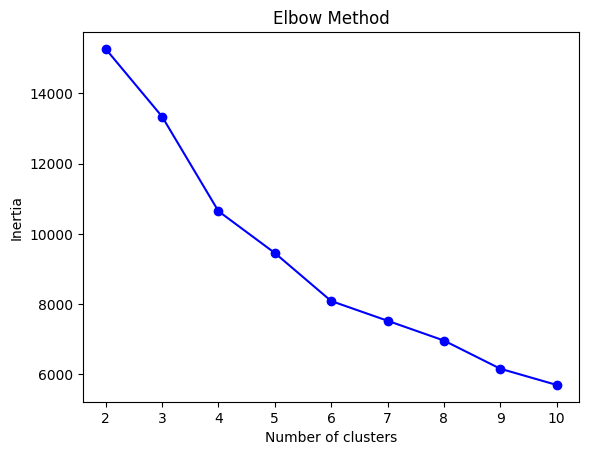

In [16]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [17]:
kmeans = KMeans(n_clusters=6, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(scaled)

# Add cluster back to main dataframe
df['Cluster'] = df_cluster['Cluster']

# See how many players in each cluster
print(df['Cluster'].value_counts())

Cluster
1    1460
5     713
4     395
2     267
0       9
3       8
Name: count, dtype: int64


In [18]:
# See average stats per cluster
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
print(cluster_profile)


         Gls_90  Ast_90  xG_90  xAG_90   PrgC    PrgP    PrgR
Cluster                                                      
0          3.66    0.23   0.93    0.16   0.67    1.22    2.89
1          0.03    0.04   0.05    0.06   5.63   17.23   11.13
2          0.25    0.20   0.24    0.20  84.02  100.79  186.25
3          0.00    4.63   0.22    3.32   0.62    1.25    2.25
4          0.40    0.13   0.43    0.14  18.71   23.91   66.79
5          0.07    0.09   0.08    0.09  32.54  101.19   56.02


In [19]:
cluster_labels = {
    0: 'Goal Poacher',
    1: 'Deep Playmaker',
    2: 'Ball Carrier',
    3: 'Assist King',
    4: 'Box to Box',
    5: 'Progressive Passer'
}

df['Player_Type'] = df['Cluster'].map(cluster_labels)

# Check
print(df[['Player', 'Pos', 'Player_Type']].head(20))

                Player    Pos         Player_Type
0           Max Aarons     DF      Deep Playmaker
1     Brenden Aaronson  MF,FW  Progressive Passer
2      Paxten Aaronson     MF      Deep Playmaker
3    Keyliane Abdallah     FW      Deep Playmaker
4     Yunis Abdelhamid     DF  Progressive Passer
5    Salis Abdul Samed     MF      Deep Playmaker
6        Nabil Aberdin     DF      Deep Playmaker
7      Laurent Abergel     MF  Progressive Passer
8       Matthis Abline     FW          Box to Box
9                Abner     DF      Deep Playmaker
10   Zakaria Aboukhlal  MF,FW          Box to Box
11         Abdel Abqar     DF      Deep Playmaker
12       Tammy Abraham     FW      Deep Playmaker
13    Francesco Acerbi     DF  Progressive Passer
14   Joshua Acheampong     DF      Deep Playmaker
15        Marcos Acuña     DF  Progressive Passer
16  Bénie Adama Traore  FW,MF      Deep Playmaker
17  Bénie Adama Traore  FW,MF      Deep Playmaker
18          Akor Adams     FW          Box to Box


In [20]:
df.to_sql("players", conn, if_exists="replace", index=False)

result = pd.read_sql("SELECT Player, Pos, Player_Type FROM players LIMIT 5", conn)
print(result)

              Player    Pos         Player_Type
0         Max Aarons     DF      Deep Playmaker
1   Brenden Aaronson  MF,FW  Progressive Passer
2    Paxten Aaronson     MF      Deep Playmaker
3  Keyliane Abdallah     FW      Deep Playmaker
4   Yunis Abdelhamid     DF  Progressive Passer


In [21]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.6 MB/s eta 0:00:00


In [23]:
from groq import Groq

from google.colab import userdata
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say hello as a football scouting AI assistant"}]
)

print(response.choices[0].message.content)

**Scouting Report Initiated**

Hello, Coach! I'm Scout-X, the advanced football scouting assistant. I'm here to provide you with detailed analysis, game footage reviews, and player profile insights to help take your team to the next level.

**Current Status:**

- Player Data Synced
- Game Footage Imported
- Team Performance Metrics Updated

How can I assist you today, Coach? Would you like to:
- Review a specific player's statistics?
- Analyze a team's defensive strategy?
- Explore new talent from our scout networks?

Please provide your request, and I'll get started on your scouting report.


In [ ]:
schema = """
Table: players
Columns: Player, Nation, Pos, Squad, Comp, Age, Min, Gls, Ast, xG, xAG,
PrgC, PrgP, PrgR, Gls_90, Ast_90, xG_90, xAG_90, CrdY, CrdR, Player_Type
"""
print(schema)

In [ ]:
def generate_sql(question):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": f"""You are a SQL expert.
            Given this database schema: {schema}
            Convert the user's football scouting question into a SQLite query.
            Return ONLY the SQL query, nothing else."""},
            {"role": "user", "content": question}
        ]
    )
    return response.choices[0].message.content


print(generate_sql("Find me the top 5 forwards by xG per 90"))

In [ ]:
def generate_sql(question):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": f"""You are a SQL expert.
            Given this database schema: {schema}
            Convert the user's football scouting question into a SQLite query.
            Return ONLY the SQL query, nothing else.
            Important notes:
            - Position values use LIKE with % for matching e.g. Pos LIKE '%FW%' for forwards, '%MF%' for midfielders, '%DF%' for defenders
            - Always use LIMIT 10 unless specified otherwise
            - Minimum 500 minutes played unless specified"""},
            {"role": "user", "content": question}
        ]
    )
    return response.choices[0].message.content

print(generate_sql("Find me the top 5 forwards by xG per 90"))


In [ ]:
def run_query(sql):
    return pd.read_sql(sql, conn)

In [ ]:
query = generate_sql("Find me top 5 forwards by xG per 90")
print(query)  # See what SQL was generated
result = run_query(query)
print(result)

In [ ]:
def generate_sql(question):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": f"""You are a SQL expert.
            Given this database schema: {schema}
            Convert the user's football scouting question into a SQLite query.
            Return ONLY the SQL query, nothing else.
            Important notes:
            - Always use SELECT * to return all columns
            - Position values use LIKE with % e.g. Pos LIKE '%FW%' for forwards
            - Always use LIMIT 10 unless specified
            - Minimum 500 minutes played unless specified"""},
            {"role": "user", "content": question}
        ]
    )
    return response.choices[0].message.content

question = "Find me the top forwards by xG per 90 with over 500 minutes"
sql = generate_sql(question)
print("Generated SQL:", sql)
result = run_query(sql)
print(result[['Player', 'Pos', 'Squad', 'Age', 'xG_90', 'Player_Type']])